# Part A: Fixed NumPy Implementation

lr = 0.1
epochs = 100
train_loss_list, test_loss_list = [], []

for epoch in range(epochs):
    # Forward pass
    train_preds = X_train*w + b
    train_loss = loss_fn(y_train, train_preds)
    # Compute gradients
    gradientw = (-2/len(X_train)) * np.sum((y_train - train_preds)*X_train)
    gradientb = (-2/len(X_train)) * np.sum(y_train - train_preds)
    # Update parameters
    w = w - gradientw*lr
    b = b - gradientb*lr
    # Evaluate on test data
    test_preds = X_test*w + b
    test_loss = loss_fn(y_test, test_preds)
    train_loss_list.append(train_loss)
    test_loss_list.append(test_loss)

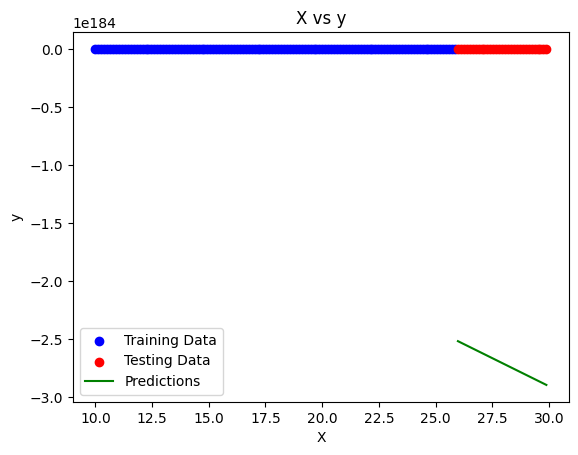

In [ ]:
y_out = X_test * w + b
plot_data(X_train, y_train, X_test, y_test, predictions=y_out)

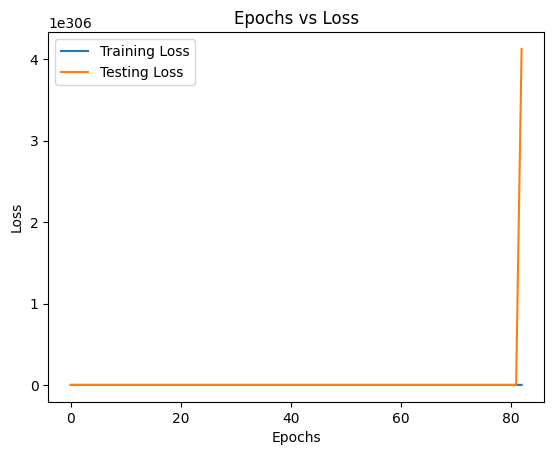

In [ ]:
plt.plot(range(epochs), train_loss_list, label="Training Loss")
plt.plot(range(epochs), test_loss_list, label="Testing Loss")
plt.title("Epochs vs Loss");
plt.xlabel("Epochs");
plt.ylabel("Loss")
plt.legend();
plt.show()

In [ ]:
print(f'Finally w={w} and b={b}')

Finally w=-9.669979538135843e+182 and b=-5.058899189698298e+181


part 2

In [ ]:
import torch
from torch import nn

if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

In [ ]:
X = np.arange(0, 1, 0.02)
y = 5.66*X + 3.227

X_train, y_train = torch.from_numpy(X_train), torch.from_numpy(y_train)
X_test, y_test = torch.from_numpy(X_test), torch.from_numpy(y_test)

In [ ]:
class LinearRegressionNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(1, requires_grad=True, dtype=torch.float))
        self.bias = nn.Parameter(torch.randn(1, requires_grad=True, dtype=torch.float))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.weights*x + self.bias

In [ ]:
torch.manual_seed(42)
model_1 = LinearRegressionNetwork()
model_1.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [ ]:
with torch.inference_mode():
    y_pred = model_1(X_test)
plot_data(predictions=y_pred)

TypeError: plot_data() missing 4 required positional arguments: 'X_train', 'y_train', 'X_test', and 'y_test'

In [ ]:
loss_fn = nn.MSELoss()
optimizer = torch.optim.SGD(params=model_1.parameters(), lr=0.1)

In [ ]:
epochs = 200
train_loss_list, test_loss_list = [], []

for epoch in range(epochs):
    model_1.train()
    train_pred = model_1(X_train)
    loss = loss_fn(y_train, train_pred)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model_1.eval()
    with torch.inference_mode():
        test_pred = model_1(X_test)
        test_loss = loss_fn(y_test, test_pred)

    train_loss_list.append(loss.detach().numpy())
    test_loss_list.append(test_loss.detach().numpy())

In [ ]:
with torch.inference_mode():
    y_pred = model_1(X_test)
plot_data(predictions=y_pred)

In [ ]:
plt.plot(range(epochs), train_loss_list, label="Training Loss")
plt.plot(range(epochs), test_loss_list, label="Testing Loss")
plt.title("Epochs vs Loss");
plt.xlabel("Epochs");
plt.ylabel("Loss")
plt.legend();
plt.show()